In [1]:
import os

DATA_DIR = "../data/raw/Tobacco3482-jpg"

classes = sorted(os.listdir(DATA_DIR))
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")

class_counts = {}
for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[cls] = num_images

print("\nImages per class:")
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {cls}: {count}")

total = sum(class_counts.values())
print(f"\nTotal images: {total}")

Number of classes: 10
Classes: ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']

Images per class:
  Memo: 620
  Email: 599
  Letter: 567
  Form: 431
  Report: 265
  Scientific: 261
  ADVE: 230
  Note: 201
  News: 188
  Resume: 120

Total images: 3482


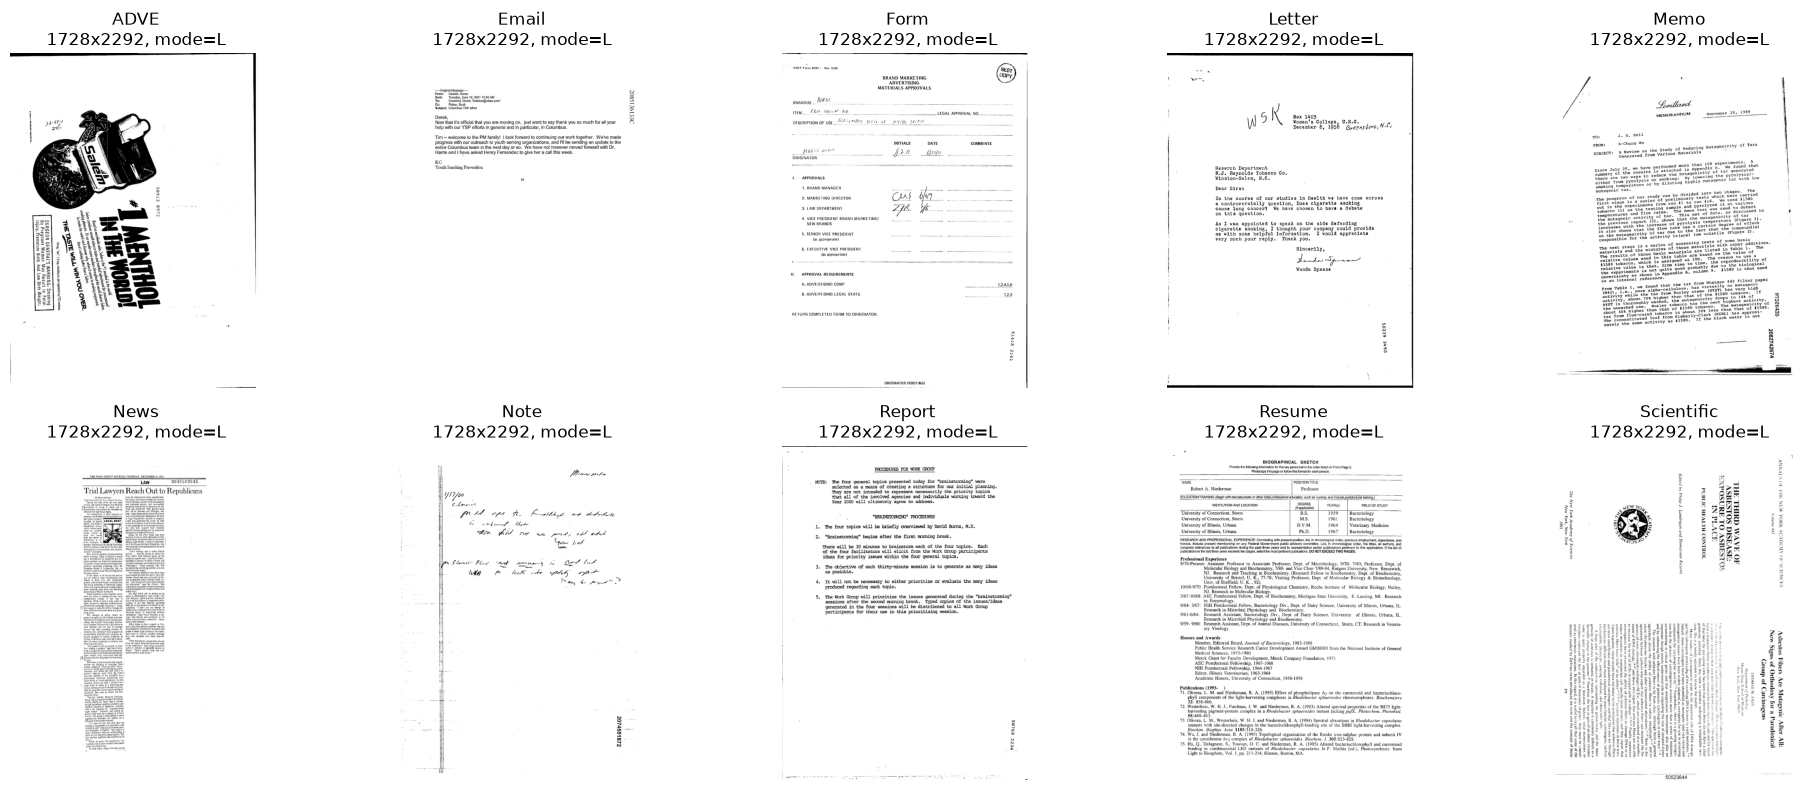

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Visualize a few sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_path = os.path.join(DATA_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_img_name = random.choice(images)
    img_path = os.path.join(cls_path, sample_img_name)
    
    img = Image.open(img_path)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"{cls}\n{img.size[0]}x{img.size[1]}, mode={img.mode}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import sys
sys.path.append('../src')
from dataset import get_all_filepaths_and_labels, create_stratified_splits

filepaths, labels, classes, class_to_idx = get_all_filepaths_and_labels()
print(f"Total files: {len(filepaths)}")
print(f"Class mapping: {class_to_idx}")

train_data, val_data, test_data = create_stratified_splits(filepaths, labels)
print(f"\nTrain size: {len(train_data[0])}")
print(f"Val size: {len(val_data[0])}")
print(f"Test size: {len(test_data[0])}")

Total files: 3482
Class mapping: {'ADVE': 0, 'Email': 1, 'Form': 2, 'Letter': 3, 'Memo': 4, 'News': 5, 'Note': 6, 'Report': 7, 'Resume': 8, 'Scientific': 9}

Train size: 2436
Val size: 523
Test size: 523


In [5]:
from dataset import DocumentDataset, train_transform, eval_transform
from torch.utils.data import DataLoader

train_dataset = DocumentDataset(train_data[0], train_data[1], transform=train_transform)
val_dataset = DocumentDataset(val_data[0], val_data[1], transform=eval_transform)
test_dataset = DocumentDataset(test_data[0], test_data[1], transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Sanity check: pull one batch and inspect shape
images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # should be [32, 1, 224, 224]
print(f"Batch labels shape: {labels.shape}")  # should be [32]
print(f"Label values: {labels}")

Batch images shape: torch.Size([32, 1, 224, 224])
Batch labels shape: torch.Size([32])
Label values: tensor([7, 5, 1, 2, 1, 4, 2, 9, 9, 9, 1, 1, 1, 9, 7, 1, 2, 2, 4, 9, 3, 3, 4, 1,
        2, 2, 9, 2, 2, 0, 4, 4])


In [6]:
import sys
sys.path.append('../src')
from model_custom import DocumentCNN
import torch

model = DocumentCNN(num_classes=10)
dummy_input = torch.randn(4, 1, 224, 224)
output = model(dummy_input)
print(f"Output shape: {output.shape}")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Output shape: torch.Size([4, 10])
Total parameters: 391,370


In [7]:
import numpy as np
from collections import Counter

# Compute class weights based on training set distribution
train_labels = train_data[1]
class_counts = Counter(train_labels)
total_samples = len(train_labels)
num_classes = 10

class_weights = []
for i in range(num_classes):
    weight = total_samples / (num_classes * class_counts[i])
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("Class weights:", class_weights)

Class weights: tensor([1.5225, 0.5814, 0.8093, 0.6136, 0.5613, 1.8455, 1.7277, 1.3168, 2.9000,
        1.3311])


In [7]:
import sys
sys.path.append('../src')
from train import train_model
from model_custom import DocumentCNN
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DocumentCNN(num_classes=10)

trained_model, history = train_model(
    model, train_loader, val_loader, class_weights, device,
    num_epochs=20, lr=0.001, patience=5
)

Using device: cpu
Epoch 1/20 (459.4s) | Train Loss: 1.7945, Train Acc: 0.3342 | Val Loss: 1.5907, Val Acc: 0.4111, Val Macro-F1: 0.3422 | LR: 0.001000
  -> New best model saved (Val Macro-F1: 0.3422)
Epoch 2/20 (397.4s) | Train Loss: 1.4767, Train Acc: 0.4692 | Val Loss: 1.4986, Val Acc: 0.3996, Val Macro-F1: 0.4112 | LR: 0.001000
  -> New best model saved (Val Macro-F1: 0.4112)
Epoch 3/20 (387.9s) | Train Loss: 1.3025, Train Acc: 0.5201 | Val Loss: 1.6026, Val Acc: 0.3442, Val Macro-F1: 0.3424 | LR: 0.001000
Epoch 4/20 (410.6s) | Train Loss: 1.2348, Train Acc: 0.5378 | Val Loss: 1.3385, Val Acc: 0.4627, Val Macro-F1: 0.4376 | LR: 0.001000
  -> New best model saved (Val Macro-F1: 0.4376)
Epoch 5/20 (417.9s) | Train Loss: 1.2169, Train Acc: 0.5489 | Val Loss: 1.5006, Val Acc: 0.4321, Val Macro-F1: 0.3991 | LR: 0.001000
Epoch 6/20 (409.8s) | Train Loss: 1.1580, Train Acc: 0.5788 | Val Loss: 1.1949, Val Acc: 0.5583, Val Macro-F1: 0.5430 | LR: 0.001000
  -> New best model saved (Val Macro-

Using device: cpu
Classification Report:

              precision    recall  f1-score   support

        ADVE      0.969     0.886     0.925        35
       Email      0.928     0.856     0.890        90
        Form      0.914     0.492     0.640        65
      Letter      0.575     0.765     0.657        85
        Memo      0.530     0.570     0.549        93
        News      0.824     1.000     0.903        28
        Note      0.618     0.700     0.656        30
      Report      0.368     0.525     0.433        40
      Resume      0.857     0.667     0.750        18
  Scientific      0.619     0.333     0.433        39

    accuracy                          0.675       523
   macro avg      0.720     0.679     0.684       523
weighted avg      0.709     0.675     0.676       523



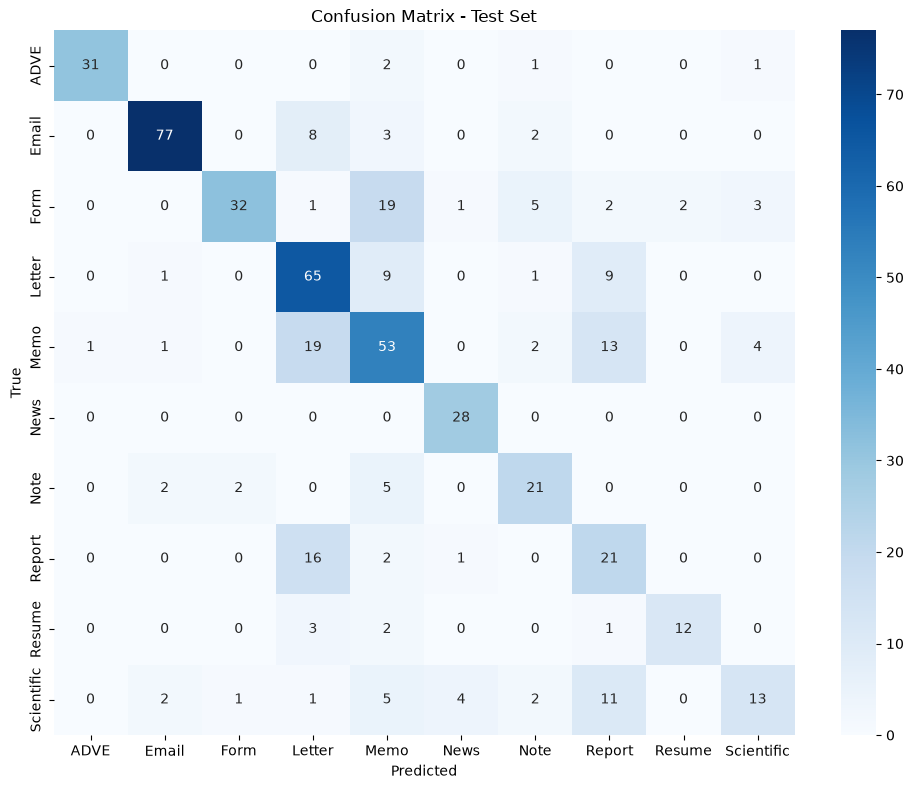

In [8]:
import sys
sys.path.append('../src')
from evaluate import evaluate_model
from model_custom import DocumentCNN
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load your best saved checkpoint
best_model = DocumentCNN(num_classes=10)
best_model.load_state_dict(torch.load('../saved_models/best_custom_cnn.pth', map_location=device))
best_model = best_model.to(device)

preds, labels = evaluate_model(best_model, test_loader, device, classes)

In [9]:
import sys
sys.path.append('../src')
from model_pretrained import get_resnet18_model
import torch

resnet_model = get_resnet18_model(num_classes=10, freeze_backbone=True)
dummy_input = torch.randn(4, 1, 224, 224)
output = resnet_model(dummy_input)
print(f"Output shape: {output.shape}")

trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in resnet_model.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\hp/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:13<00:00, 3.59MB/s]


Output shape: torch.Size([4, 10])
Trainable parameters: 5,130 / 11,175,370


In [10]:
from train import train_model
from model_pretrained import get_resnet18_model
import torch

resnet_model = get_resnet18_model(num_classes=10, freeze_backbone=True)

trained_resnet, resnet_history = train_model(
    resnet_model, train_loader, val_loader, class_weights, device,
    num_epochs=20, lr=0.001, patience=5,
    checkpoint_path="../saved_models/best_resnet18.pth"
)

Epoch 1/20 (323.2s) | Train Loss: 1.9008, Train Acc: 0.3514 | Val Loss: 1.6681, Val Acc: 0.4455, Val Macro-F1: 0.3507 | LR: 0.001000
  -> New best model saved (Val Macro-F1: 0.3507)
Epoch 2/20 (319.6s) | Train Loss: 1.4120, Train Acc: 0.5472 | Val Loss: 1.2243, Val Acc: 0.5908, Val Macro-F1: 0.5881 | LR: 0.001000
  -> New best model saved (Val Macro-F1: 0.5881)
Epoch 3/20 (308.1s) | Train Loss: 1.2335, Train Acc: 0.5920 | Val Loss: 1.1205, Val Acc: 0.6539, Val Macro-F1: 0.6393 | LR: 0.001000
  -> New best model saved (Val Macro-F1: 0.6393)
Epoch 4/20 (320.5s) | Train Loss: 1.1480, Train Acc: 0.6096 | Val Loss: 1.0464, Val Acc: 0.6902, Val Macro-F1: 0.6597 | LR: 0.001000
  -> New best model saved (Val Macro-F1: 0.6597)
Epoch 5/20 (325.6s) | Train Loss: 1.0689, Train Acc: 0.6494 | Val Loss: 1.0190, Val Acc: 0.6501, Val Macro-F1: 0.6440 | LR: 0.001000
Epoch 6/20 (330.0s) | Train Loss: 1.0157, Train Acc: 0.6552 | Val Loss: 0.9742, Val Acc: 0.6501, Val Macro-F1: 0.6401 | LR: 0.001000
Epoch 

Classification Report:

              precision    recall  f1-score   support

        ADVE      0.850     0.971     0.907        35
       Email      0.933     0.922     0.927        90
        Form      0.632     0.846     0.724        65
      Letter      0.833     0.471     0.602        85
        Memo      0.659     0.581     0.617        93
        News      0.897     0.929     0.912        28
        Note      0.704     0.633     0.667        30
      Report      0.415     0.675     0.514        40
      Resume      0.722     0.722     0.722        18
  Scientific      0.474     0.462     0.468        39

    accuracy                          0.706       523
   macro avg      0.712     0.721     0.706       523
weighted avg      0.729     0.706     0.704       523



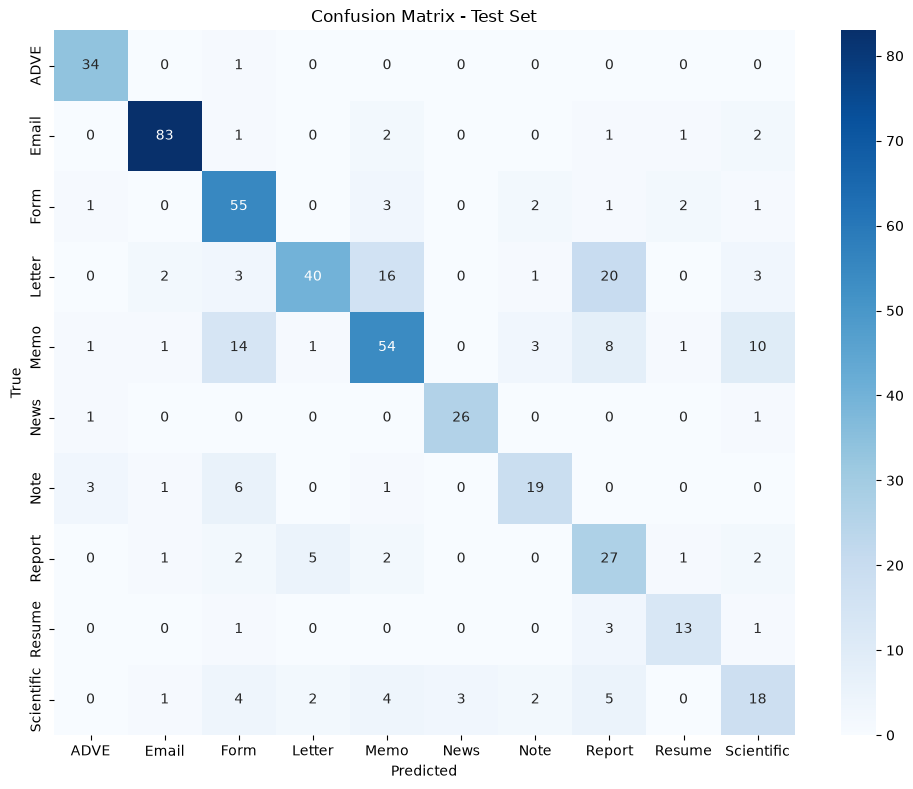

In [9]:
from model_pretrained import get_resnet18_model
from evaluate import evaluate_model
import torch

resnet_model = get_resnet18_model(num_classes=10, freeze_backbone=True)
resnet_model.load_state_dict(torch.load('../saved_models/best_resnet18.pth', map_location=device))
resnet_model = resnet_model.to(device)

resnet_preds, resnet_labels = evaluate_model(resnet_model, test_loader, device, classes)

In [13]:
import importlib
import gradcam
importlib.reload(gradcam)
from gradcam import visualize_gradcam

True class: Scientific


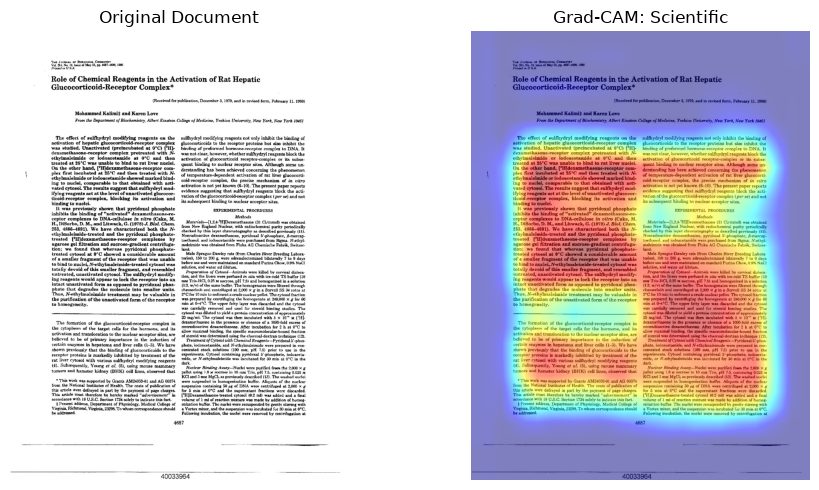

In [18]:
import sys
sys.path.append('../src')
from gradcam import visualize_gradcam
from model_custom import DocumentCNN
from PIL import Image
from dataset import eval_transform
import torch

# Load your trained custom CNN
model = DocumentCNN(num_classes=10)
model.load_state_dict(torch.load('../saved_models/best_custom_cnn.pth', map_location=device))
model = model.to(device)

# Pick a sample test image to visualize
sample_idx = 7 # try changing this to explore different examples
sample_path = test_data[0][sample_idx]
true_label = test_data[1][sample_idx]

image_pil = Image.open(sample_path).convert('L')
input_tensor = eval_transform(image_pil).unsqueeze(0).to(device)  # add batch dimension

print(f"True class: {classes[true_label]}")

# Target layer: the last conv block before pooling
target_layer = model.block4.conv

overlayed, predicted_class = visualize_gradcam(
    model, target_layer, image_pil, input_tensor, classes
)

In [23]:
import importlib
import gradcam
importlib.reload(gradcam)
from gradcam import visualize_gradcam

True class: Letter


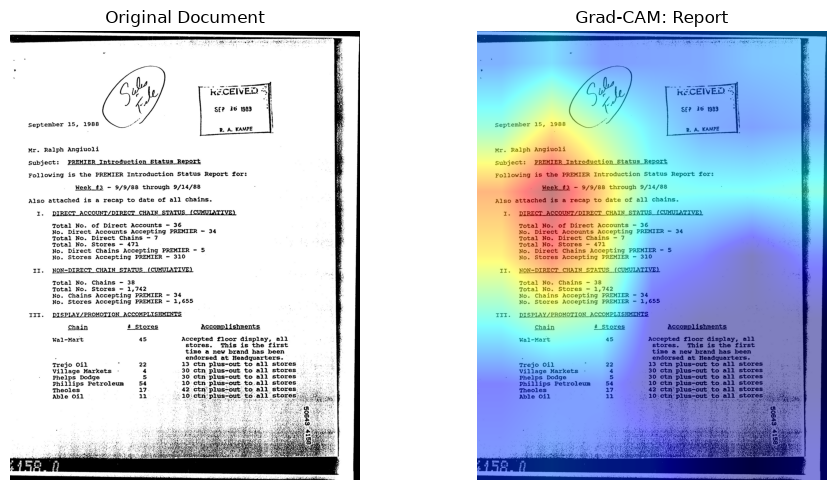

In [24]:
from model_pretrained import get_resnet18_model
from gradcam import visualize_gradcam
import torch

# Load your trained ResNet18
resnet_model = get_resnet18_model(num_classes=10, freeze_backbone=True)
resnet_model.load_state_dict(torch.load('../saved_models/best_resnet18.pth', map_location=device))
resnet_model = resnet_model.to(device)

# Use the SAME sample image as before for direct comparison
sample_idx = 6
sample_path = test_data[0][sample_idx]
true_label = test_data[1][sample_idx]

image_pil = Image.open(sample_path).convert('L')
input_tensor = eval_transform(image_pil).unsqueeze(0).to(device)

print(f"True class: {classes[true_label]}")

# Target layer for ResNet18: last conv layer in the final residual block
target_layer = resnet_model.layer4[-1].conv2

overlayed, predicted_class = visualize_gradcam(
    resnet_model, target_layer, image_pil, input_tensor, classes
)

In [32]:
import sys
sys.path.append('../src')
from routing import predict_with_confidence_routing, print_prediction_result

result = predict_with_confidence_routing(model, input_tensor, classes, confidence_threshold=0.6)
print_prediction_result(result)

Predicted class: Report
Confidence: 44.2%
⚠️  LOW CONFIDENCE — Flagged for manual review

Top 3 predictions:
  Report: 44.2%
  Letter: 30.6%
  Memo: 12.1%


In [31]:
from routing import predict_with_confidence_routing
from dataset import eval_transform
from PIL import Image
import torch

def analyze_routing_on_testset(model, test_data, class_names, device, confidence_threshold=0.6):
    flagged_count = 0
    flagged_but_correct = 0
    flagged_but_wrong = 0
    not_flagged_but_wrong = 0
    total = len(test_data[0])

    for i in range(total):
        img_path = test_data[0][i]
        true_label = test_data[1][i]
        true_class = class_names[true_label]

        image_pil = Image.open(img_path).convert('L')
        input_tensor = eval_transform(image_pil).unsqueeze(0).to(device)

        result = predict_with_confidence_routing(model, input_tensor, class_names, confidence_threshold)

        predicted_correctly = (result["predicted_class"] == true_class)

        if result["needs_manual_review"]:
            flagged_count += 1
            if predicted_correctly:
                flagged_but_correct += 1
            else:
                flagged_but_wrong += 1
        else:
            if not predicted_correctly:
                not_flagged_but_wrong += 1

    print(f"Total test images: {total}")
    print(f"Flagged for review: {flagged_count} ({flagged_count/total:.1%})")
    print(f"  - Flagged AND actually wrong: {flagged_but_wrong} (routing caught a real error)")
    print(f"  - Flagged BUT actually correct: {flagged_but_correct} (unnecessary flag, but safe)")
    print(f"Not flagged BUT actually wrong: {not_flagged_but_wrong} (missed error -- routing didn't catch this)")

analyze_routing_on_testset(model, test_data, classes, device, confidence_threshold=0.5)

Total test images: 523
Flagged for review: 249 (47.6%)
  - Flagged AND actually wrong: 130 (routing caught a real error)
  - Flagged BUT actually correct: 119 (unnecessary flag, but safe)
Not flagged BUT actually wrong: 40 (missed error -- routing didn't catch this)


In [33]:
from routing import predict_with_confidence_routing
from dataset import eval_transform
from PIL import Image
import torch

def analyze_routing_on_testset(model, test_data, class_names, device, confidence_threshold=0.6):
    flagged_count = 0
    flagged_but_correct = 0
    flagged_but_wrong = 0
    not_flagged_but_wrong = 0
    total = len(test_data[0])

    for i in range(total):
        img_path = test_data[0][i]
        true_label = test_data[1][i]
        true_class = class_names[true_label]

        image_pil = Image.open(img_path).convert('L')
        input_tensor = eval_transform(image_pil).unsqueeze(0).to(device)

        result = predict_with_confidence_routing(model, input_tensor, class_names, confidence_threshold)

        predicted_correctly = (result["predicted_class"] == true_class)

        if result["needs_manual_review"]:
            flagged_count += 1
            if predicted_correctly:
                flagged_but_correct += 1
            else:
                flagged_but_wrong += 1
        else:
            if not predicted_correctly:
                not_flagged_but_wrong += 1

    print(f"Total test images: {total}")
    print(f"Flagged for review: {flagged_count} ({flagged_count/total:.1%})")
    print(f"  - Flagged AND actually wrong: {flagged_but_wrong} (routing caught a real error)")
    print(f"  - Flagged BUT actually correct: {flagged_but_correct} (unnecessary flag, but safe)")
    print(f"Not flagged BUT actually wrong: {not_flagged_but_wrong} (missed error -- routing didn't catch this)")

analyze_routing_on_testset(model, test_data, classes, device, confidence_threshold=0.45)

Total test images: 523
Flagged for review: 201 (38.4%)
  - Flagged AND actually wrong: 111 (routing caught a real error)
  - Flagged BUT actually correct: 90 (unnecessary flag, but safe)
Not flagged BUT actually wrong: 59 (missed error -- routing didn't catch this)
